In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_iris
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler

TEST_SIZE = 0.2
RANDOM_STATE = 42
MAX_ITER = 5000

np.random.seed(RANDOM_STATE)

# Part 1: Two-Layer Neural Network from Scratch


In [2]:
iris = load_iris()
X, y = np.array(iris.data), np.array(iris.target).reshape(-1, 1)

# Encoding
enc = OneHotEncoder(sparse_output=False)
y = enc.fit_transform(y)

# Splitting
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).T
X_test = scaler.transform(X_test).T
y_train, y_test = y_train.T, y_test.T

In [3]:
def sigmoid(Z: np.ndarray):
    Z = np.clip(Z, -500, 500)
    return 1.0 / (1.0 + np.exp(-Z))


def sigmoid_prime(Z: np.ndarray):
    s = sigmoid(Z)
    return s * (1.0 - s)


def compute_loss(Y: np.ndarray, A2: np.ndarray, epsilon: float = 1e-15):
    m = Y.shape[1]
    loss = -(1.0 / m) * np.sum(
        Y * np.log(A2 + epsilon) + (1.0 - Y) * np.log(1.0 - A2 + epsilon)
    )
    return float(np.squeeze(loss))


def train_nn(
    X: np.ndarray, Y: np.ndarray, n_h: int, learning_rate: float, iterations: int
):
    n_x = X.shape[0]
    n_y = Y.shape[0]
    m = X.shape[1]

    params = {
        "W1": np.random.randn(n_h, n_x) * np.sqrt(1.0 / n_x),
        "b1": np.zeros((n_h, 1)),
        "W2": np.random.randn(n_y, n_h) * np.sqrt(1.0 / n_h),
        "b2": np.zeros((n_y, 1)),
    }
    error_list = []

    for _ in range(iterations):
        # --- Forward Propagation ---
        Z1 = np.dot(params["W1"], X) + params["b1"]
        A1 = sigmoid(Z1)
        Z2 = np.dot(params["W2"], A1) + params["b2"]
        A2 = sigmoid(Z2)

        # --- Backpropagation ---
        dZ2 = A2 - Y
        dW2 = (1.0 / m) * np.dot(dZ2, A1.T)
        db2 = (1.0 / m) * np.sum(dZ2, axis=1, keepdims=True)

        dZ1 = np.dot(params["W2"].T, dZ2) * sigmoid_prime(Z1)
        dW1 = (1.0 / m) * np.dot(dZ1, X.T)
        db1 = (1.0 / m) * np.sum(dZ1, axis=1, keepdims=True)

        # --- Gradient Descent Update ---
        params["W1"] -= learning_rate * dW1
        params["b1"] -= learning_rate * db1
        params["W2"] -= learning_rate * dW2
        params["b2"] -= learning_rate * db2

        loss = compute_loss(Y, A2)
        error_list.append(loss)

    return params, error_list

In [4]:
params, error_list = train_nn(X_train, y_train, 10, 0.1, MAX_ITER)

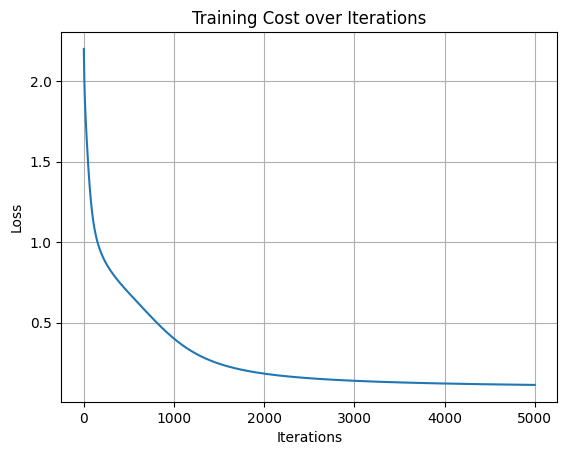

In [5]:
plt.plot(range(len(error_list)), error_list)
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Training Cost over Iterations")
plt.grid(True)
plt.show()

In [6]:
Z1 = np.dot(params["W1"], X_test) + params["b1"]
A1 = sigmoid(Z1)
Z2 = np.dot(params["W2"], A1) + params["b2"]
A2 = sigmoid(Z2)

y_pred = np.argmax(A2, axis=0)
actual = np.argmax(y_test, axis=0)
accuracy = np.mean(y_pred == actual)
print(f"Accuracy Score: {accuracy * 100:.2f}%")
print(
    "Confusion Matrix:\n",
    confusion_matrix(actual, y_pred),
)
print("Classification Report:\n", classification_report(actual, y_pred))

Accuracy Score: 100.00%
Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



# Part 2: Multi-layer Perceptron (MLP)


In [7]:
iris = load_iris()
X, y = np.array(iris.data), np.array(iris.target).reshape(-1, 1)

# Encoding
enc = OneHotEncoder(sparse_output=False)
y = enc.fit_transform(y)

# Splitting
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

In [8]:
clf = MLPClassifier(random_state=RANDOM_STATE, max_iter=MAX_ITER).fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("Accuracy Score:", clf.score(X_test, y_test))
print(
    "Confusion Matrix:\n",
    confusion_matrix(y_test.argmax(axis=1), y_pred.argmax(axis=1)),
)
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy Score: 1.0
Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

   micro avg       1.00      1.00      1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30
 samples avg       1.00      1.00      1.00        30



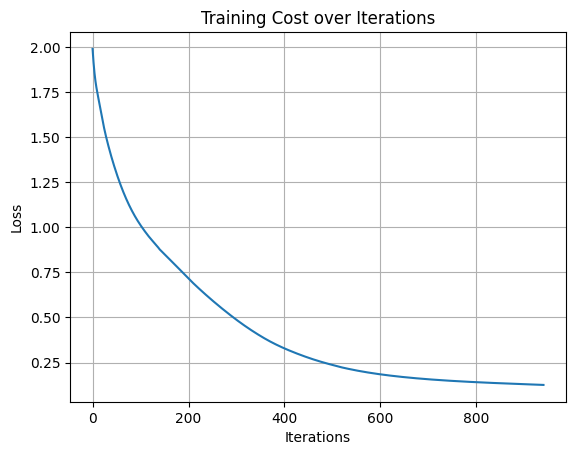

In [9]:
plt.plot(clf.loss_curve_)
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Training Cost over Iterations")
plt.grid(True)
plt.show()